# Procure-to-Pay & Supplier Performance

**Atul Iwale · AEC Intelligence Portfolio · executed synthetic-data walkthrough**

> **Decision:** Where should buyers and finance investigate delivery and payment exceptions?

[Case study](https://github.com/AtulIwale/Portfolio/tree/main/projects/03-control-tower) ·
[Data assumptions](https://github.com/AtulIwale/Portfolio/blob/main/docs/DATA_CARD.md) ·
[Portfolio](https://github.com/AtulIwale/Portfolio)

Read the narrative, tables and saved charts on GitHub; no installation is required to read.
To reproduce, use **Runtime → Run all** in a fresh Colab session. The first cell downloads
the public repository and installs dependencies only in Colab. Locally, install
`requirements-notebooks.txt` and open this notebook from the repository.

All data is fictional. Results demonstrate an analytical approach, not proven client impact.

## 1. Reproducible setup

The notebook verifies the dataset hashes and imports reusable project functions. The
important decisions and calculations remain visible below. Saved outputs were produced
by executing all cells in a fresh Python process with IPython rich output capture.
Local Jupyter kernel sockets were unavailable; the hosted Colab service was not used for validation.

In [1]:
from pathlib import Path
import os, sys, subprocess, tempfile

# Pin the computational source/data so later edits to main do not change this walkthrough.
SOURCE_REV = "363f7edcd6c2357bc167257fce4e36b771b216d6"
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "aec/features.py").exists()), None)
if ROOT is None:
    ROOT = Path(tempfile.mkdtemp(prefix="aec-portfolio-")) / "Portfolio"
    subprocess.run(["git", "clone", "--quiet", "https://github.com/AtulIwale/Portfolio.git", str(ROOT)], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "--quiet", SOURCE_REV], check=True)
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "requirements.txt"), "matplotlib==3.10.8"], check=True)
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
print("Source:", SOURCE_REV if IN_COLAB else "local checkout")
print("Data: synthetic only; no client information or credentials required.")

Source: local checkout
Data: synthetic only; no client information or credentials required.


In [2]:
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aec.data import load_dataset

tables = load_dataset(ROOT / "data")
manifest = json.loads((ROOT / "data/manifest.json").read_text())
for name, spec in manifest["tables"].items():
    assert hashlib.sha256((ROOT / f"data/{name}.jsonl").read_bytes()).hexdigest() == spec["sha256"], name
plt.rcParams.update({"figure.figsize": (10, 4.8), "figure.dpi": 120,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#2D4653", "text.color": "#2D4653", "axes.titleweight": "bold",
    "axes.prop_cycle": plt.cycler(color=["#3F7285", "#B6A78E", "#2D4653", "#899BA5"])})
FIGURES = ROOT / "outputs/notebook-figures"
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
print(f"Verified {len(tables)} tables / {sum(len(t) for t in tables.values()):,} synthetic rows against manifest hashes.")

Verified 12 tables / 28,682 synthetic rows against manifest hashes.


## 2. Understand the records before joining them

An order can have multiple receipts; an invoice can have multiple payment instalments.
I first establish the grain of each table. Joining every detail row and then summing order
values would repeat the same commitment. The report must retain **one row per order**.

Only INR is present. Taxes, retention, credit notes and cancellations are not simulated.

In [3]:
keys = {"orders":"order_id", "grns":"grn_id", "invoices":"invoice_id", "payments":"payment_id"}
display(pd.DataFrame([{"table":n,"rows":len(tables[n]),"unique_primary_keys":tables[n][k].nunique(),
    "missing_cells":int(tables[n].isna().sum().sum())} for n,k in keys.items()]))
display(tables["orders"].head(5))

,table,rows,unique_primary_keys,missing_cells
0,orders,3600,3600,0
1,grns,4733,4733,0
2,invoices,4709,4709,0
3,payments,5414,5414,0


,order_id,requisition_id,project_id,supplier_id,order_date,required_by,category,quantity,unit_rate,amount,currency
0,O000000,RQ000000,P022,S001,2022-01-01,2022-01-17,Earthworks,430,186.88,80358.40,INR
1,O000001,RQ000001,P002,S056,2022-01-01,2022-02-12,Earthworks,642,229.82,147544.44,INR
2,O000002,RQ000002,P016,S041,2022-01-02,2022-02-25,Finishes,280,151.15,42322.00,INR
3,O000003,RQ000003,P004,S060,2022-01-02,2022-01-21,MEP,36,340.32,12251.52,INR
4,O000004,RQ000004,P014,S014,2022-01-02,2022-02-18,MEP,365,554.54,202407.10,INR


## 3. Audit quality without contaminating the clean analysis

The clean generator is intentionally complete, so “zero missing values” is not evidence
that real ERP data is clean. A separate damaged fixture tests unknown suppliers, negative
values, impossible dates and duplicate references. Flagging a record does not authorise
silently repairing it.

In [4]:
from aec.analytics import audit_orders, control_tower, CONTROL_TOWER_SQL
findings = pd.DataFrame(audit_orders(tables["orders_dirty"], tables["suppliers"]))
display(findings)
assert audit_orders(tables["orders"], tables["suppliers"]) == []
print("Dirty fixture findings:", len(findings), "| clean data kept separate")

Dirty fixture findings: 5 | clean data kept separate


,row_index,order_id,rule,action
0,0,O000000,UNKNOWN_SUPPLIER,Review source record; do not auto-correct.
1,1,O000001,NEGATIVE_ORDER_VALUE,Review source record; do not auto-correct.
2,2,O000002,REQUIRED_BEFORE_ORDER,Review source record; do not auto-correct.
3,3,O000003,DUPLICATE_ORDER_ID,Review source record; do not auto-correct.
4,100,O000003,DUPLICATE_ORDER_ID,Review source record; do not auto-correct.


## 4. Demonstrate the join problem and the correction

The first calculation below is deliberately wrong: it sums order value after expanding
receipt detail. The correct SQL aggregates receipts and payment instalments before the
order-level join. This is a financial-control decision, not just a coding preference.

In [5]:
naive = tables["orders"].merge(tables["grns"], on="order_id", how="left")
correct_value = tables["orders"].amount.sum()
display(pd.DataFrame({"calculation":["Incorrect: sum after detail join","Correct: unique orders"],
    "INR":[naive.amount.sum(),correct_value]}).round(2))
print(f"Illustrative join inflation: {(naive.amount.sum()/correct_value-1):.1%}")
print(CONTROL_TOWER_SQL)

Illustrative join inflation: 34.0%

WITH receipts AS (
 SELECT order_id, SUM(quantity) AS received_qty,
 SUM(rejected_quantity) AS rejected_qty, MAX(received_date) AS last_receipt
 FROM grns GROUP BY order_id
), invoice_payment AS (
 SELECT i.invoice_id, i.order_id, i.amount, i.due_date,
 COALESCE(SUM(p.amount),0) AS paid
 FROM invoices i LEFT JOIN payments p ON p.invoice_id=i.invoice_id
 GROUP BY i.invoice_id, i.order_id, i.amount, i.due_date
), billing AS (
 SELECT order_id, SUM(amount) AS invoiced, SUM(paid) AS paid,
 SUM(CASE WHEN due_date < :as_of THEN MAX(amount-paid,0) ELSE 0 END) AS overdue
 FROM invoice_payment GROUP BY order_id
)
SELECT o.order_id,o.project_id,o.supplier_id,o.category,o.amount,o.quantity,
 o.order_date,o.required_by,o.currency,
 COALESCE(r.received_qty,0) AS received_qty,
 COALESCE(r.rejected_qty,0) AS rejected_qty,r.last_receipt,
 COALESCE(b.invoiced,0) AS invoiced,COALESCE(b.paid,0) AS paid,
 COALESCE(b.overdue,0) AS overdue,
 MAX(o.amount-COALESCE(b.invoic

,calculation,INR
0,Incorrect: sum after detail join,5.445373e+08
1,Correct: unique orders,4.063433e+08


In [6]:
summary, detail, suppliers = control_tower(tables)
checks = pd.DataFrame({"source":["Orders","Invoices","Payments"],
    "register_total":[tables["orders"].amount.sum(),tables["invoices"].amount.sum(),tables["payments"].amount.sum()],
    "report_total":[detail.amount.sum(),detail.invoiced.sum(),detail.paid.sum()]})
checks["difference"] = checks.report_total-checks.register_total
assert np.allclose(checks.difference, 0, atol=.01)
display(checks.round(2))

,source,register_total,report_total,difference
0,Orders,4.063433e+08,4.063433e+08,0.0
1,Invoices,3.938330e+08,3.938330e+08,0.0
2,Payments,3.825615e+08,3.825615e+08,0.0


## 5. Explore time and supplier performance

The monthly view uses **order issue month**, not receipt month. The supplier chart shows
the twelve suppliers with the most completed orders, selected by volume rather than
worst-looking rates. Each rate excludes incomplete orders; the open-order analysis follows.
These comparisons are descriptive, not supplier performance assessments in the real world.

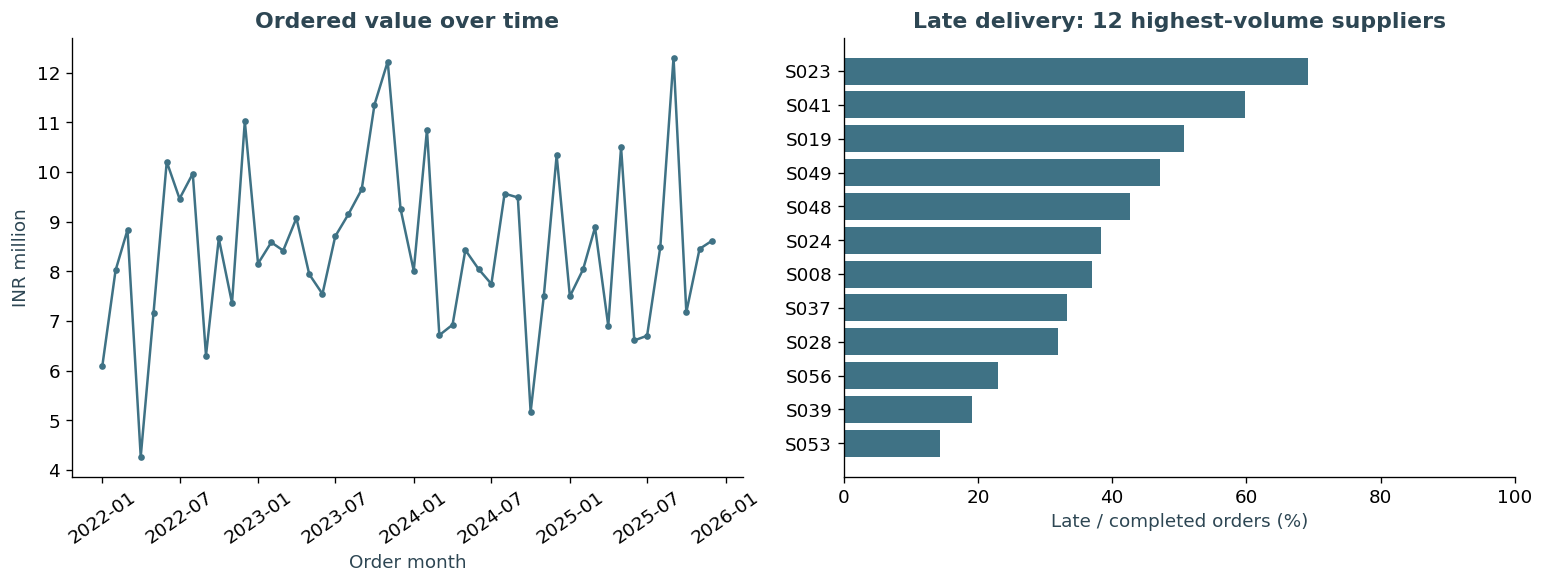

,supplier_id,completed,late_completed,overdue_open
52,S053,70,10,0
38,S039,68,13,0
55,S056,74,17,0
27,S028,69,22,0
36,S037,72,24,0
7,S008,73,27,0
23,S024,73,28,0
47,S048,68,29,0
48,S049,68,32,1
18,S019,69,35,1


In [7]:
monthly = detail.assign(month=pd.to_datetime(detail.order_date).dt.to_period("M").dt.to_timestamp()).groupby("month").amount.sum()
top = suppliers.nlargest(12,"completed").sort_values("late_completed_rate")
fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].plot(monthly.index, monthly.values/1e6, marker=".")
axes[0].set(title="Ordered value over time",ylabel="INR million",xlabel="Order month")
axes[0].tick_params(axis="x",rotation=35)
axes[1].barh(top.supplier_id,top.late_completed_rate*100)
axes[1].set(title="Late delivery: 12 highest-volume suppliers",xlabel="Late / completed orders (%)",xlim=(0,100))
finish(fig,"03-procurement-overview")
display(top[["supplier_id","completed","late_completed","overdue_open"]])

## 6. Turn findings into review queues

Overdue invoices and overdue-open orders need different owners. Outstanding value is not
automatically loss, and a missing receipt can reflect export timing. I show separate queues
instead of combining unlike problems into a vague risk score.

,Value
as_of,2025-12-31
currency,INR
orders,3600
order_value,406343330.61
invoiced_value,393833031.86
paid_value,382561540.12
overdue_invoice_balance,3749467.82
uninvoiced_commitment,12510298.75
completed_orders,3500
on_time_completed_rate,0.61


,order_id,project_id,supplier_id,required_by,received_qty,quantity
3418,O003418,P014,S052,2025-12-18,0.0,529
3421,O003421,P006,S031,2025-12-21,0.0,465
3428,O003428,P028,S031,2025-12-28,0.0,464
3467,O003467,P014,S019,2025-12-17,0.0,174
3510,O003510,P021,S049,2025-12-20,0.0,534
3560,O003560,P020,S029,2025-12-29,0.0,636


,order_id,supplier_id,invoiced,paid,overdue
3290,O003290,S040,1001723.85,300517.16,701206.69
3402,O003402,S016,394913.10,0.00,394913.10
3297,O003297,S040,235433.25,0.00,235433.25
3315,O003315,S011,380719.92,152287.97,228431.95
3284,O003284,S052,370912.74,222547.64,148365.10
3287,O003287,S045,203408.40,81363.36,122045.04
3352,O003352,S041,110842.17,0.00,110842.17
3403,O003403,S028,261205.56,0.00,104482.22
3338,O003338,S052,101168.73,0.00,101168.73
3360,O003360,S020,97084.56,0.00,97084.56


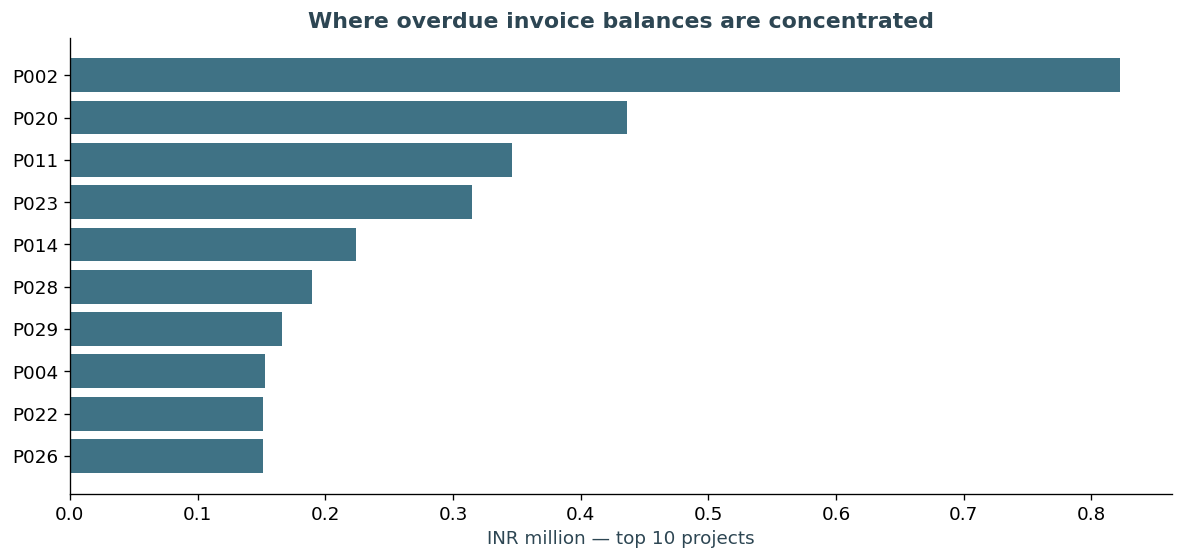

In [8]:
display(pd.Series(summary,name="Value").to_frame())
display(detail.loc[detail.overdue_open,["order_id","project_id","supplier_id","required_by","received_qty","quantity"]])
display(detail.nlargest(10,"overdue")[["order_id","supplier_id","invoiced","paid","overdue"]])
fig,ax=plt.subplots()
by_project=detail.groupby("project_id").overdue.sum().nlargest(10).sort_values()
ax.barh(by_project.index,by_project.values/1e6)
ax.set(title="Where overdue invoice balances are concentrated",xlabel="INR million — top 10 projects")
finish(fig,"03-overdue-exposure")

## 7. Recommendation and limitations

- Buyers investigate overdue-open orders, confirming whether they are still required.
- AP verifies payment holds and missing receipts before chasing all overdue balances alike.
- The analyst reconciles totals on every refresh and records the extract cutoff.
- Material rejection rates should be compared within compatible units. This simplified
  dataset has no defensible cross-material UOM conversion, so I do not use its overall
  quantity rejection percentage to rank real suppliers.

**What this demonstrates:** SQL grain control, quality checks, KPI definitions and actionable
reporting. **What it does not demonstrate:** actual savings, root-cause causality or a live ERP
dashboard. Missing currency/tax/retention/cancellation rules would be discovery requirements.

**Interview discussion:** Why does a detail join inflate totals? Why report open orders beside
completed-order delivery rates? Which exceptions need a business owner rather than automatic correction?